Step     0: ELBO = -33443.1293
Step   100: ELBO = -13272.4435
Step   200: ELBO = -1691.5379
Step   300: ELBO = 8127.9895
Step   400: ELBO = 14181.3721
Step   500: ELBO = 16814.0945
Step   600: ELBO = 17208.7551
Step   700: ELBO = 17232.8690
Step   800: ELBO = 18197.1084
Step   900: ELBO = 17415.2619
Step  1000: ELBO = 17813.9078
Step  1100: ELBO = 16980.2023
Step  1200: ELBO = 17454.8218
Step  1300: ELBO = 17478.0565
Step  1400: ELBO = 18549.5068
Step  1500: ELBO = 18308.6202
Step  1600: ELBO = 16668.6372
Step  1700: ELBO = 18696.1797
Step  1800: ELBO = 17461.6279
Step  1900: ELBO = 18796.3798
Optimization finished.


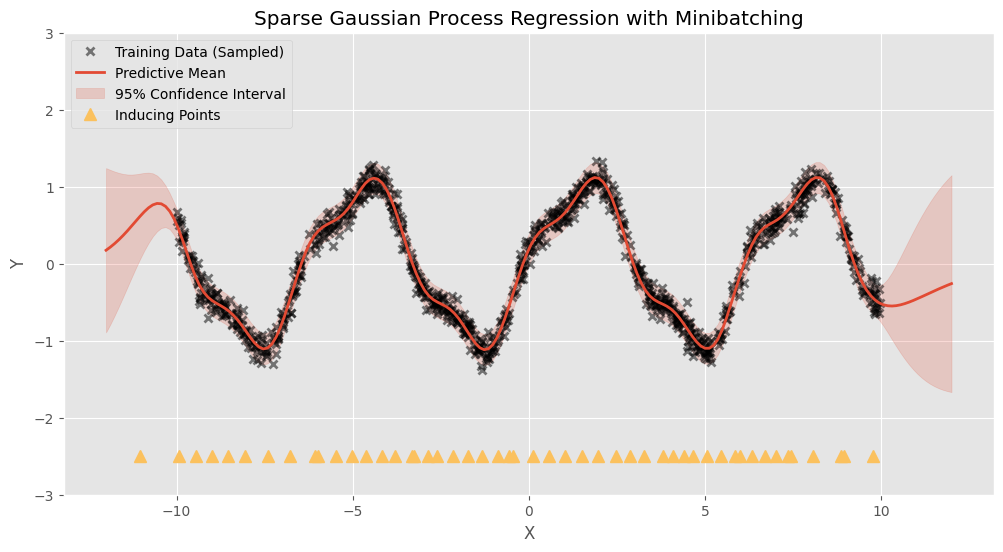

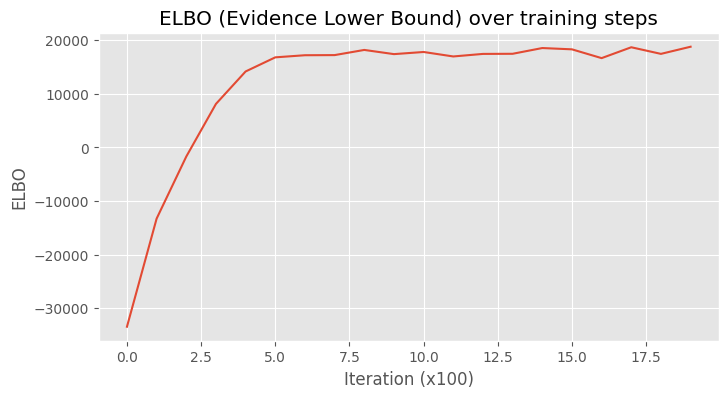

In [ ]:
import numpy as np
import tensorflow as tf
import gpflow
import matplotlib.pyplot as plt

# Matplotlibのスタイル設定
plt.style.use("ggplot")

# 1. 大規模なダミーデータの生成
# ------------------------------------
# N: データ点数
N = 20000
# X: 入力データ (-10から10までの一様分布)
X = np.random.uniform(-10.0, 10.0, (N, 1))
# 真の関数にノイズを加えたものを観測値Yとする
# f(x) = sin(x) + 0.2 * cos(3x)
Y = np.sin(X) + 0.2 * np.cos(3 * X) + np.random.randn(N, 1) * 0.1

# データをTensorFlowのテンソルに変換
X = tf.convert_to_tensor(X, dtype=gpflow.default_float())
Y = tf.convert_to_tensor(Y, dtype=gpflow.default_float())

# 2. データパイプラインの構築 (`tf.data.Dataset`)
# ------------------------------------
# ミニバッチサイズ
batch_size = 256

# データセットを作成し、シャッフル、バッチ化、リピートを行う
# .prefetch()は、モデルが現在のバッチで学習している間に、次のバッチを準備しておくことでパフォーマンスを向上させる
train_dataset = tf.data.Dataset.from_tensor_slices((X, Y)) \
    .shuffle(buffer_size=N) \
    .batch(batch_size) \
    .repeat()

# 3. モデルの定義 (`gpflow.models.SVGP`)
# ------------------------------------
# M: 誘導点の数 (データ点数Nより大幅に小さい値を選ぶ)
M = 50

# カーネルの選択 (ここではMatern 5/2カーネルを使用)
kernel = gpflow.kernels.Matern52()

# 誘導点の初期位置をK-Meansで決定する
# これにより、データが密な領域に誘導点が配置されやすくなり、学習が安定・高速化する
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=M, random_state=0, n_init='auto').fit(X.numpy())
inducing_variable = kmeans.cluster_centers_

# SVGPモデルの構築
# likelihoodは観測ノイズのモデル
model = gpflow.models.SVGP(
    kernel=kernel,
    likelihood=gpflow.likelihoods.Gaussian(),
    inducing_variable=inducing_variable,
    num_data=N  # データセットの総数をモデルに伝える
)

# 4. 最適化の準備
# ------------------------------------
# オプティマイザの選択 (Adamが一般的に使われる)
optimizer = tf.optimizers.Adam(learning_rate=0.01)

# 学習の進捗を記録するためのリスト
log_elbo = []

# 5. 最適化ループの実行
# ------------------------------------
# トレーニングステップ数
training_steps = 2000

# データセットからイテレータを作成
train_iterator = iter(train_dataset)

# `tf.function`デコレータは、Pythonの関数を高性能なTensorFlowのグラフにコンパイルする
# これにより、特にループ処理が大幅に高速化される
@tf.function
def optimization_step(model, batch):
    with tf.GradientTape() as tape:
        # モデルの損失(負のELBO)を計算
        loss = model.training_loss(batch)
    # 勾配を計算
    grads = tape.gradient(loss, model.trainable_variables)
    # オプティマイザを使ってモデルのパラメータを更新
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# 最適化ループ
for step in range(training_steps):
    # ミニバッチを取得
    data_batch = next(train_iterator)
    
    # 最適化ステップを実行
    loss = optimization_step(model, data_batch)
    
    if step % 100 == 0:
        elbo = -loss.numpy()
        log_elbo.append(elbo)
        print(f"Step {step:5d}: ELBO = {elbo:.4f}")

print("Optimization finished.")

# 6. 結果の可視化
# ------------------------------------
# テスト用の入力データを作成
xx = np.linspace(-12, 12, 200).reshape(-1, 1)

# 予測平均と予測分散を計算
mean, var = model.predict_y(xx)

# プロット
plt.figure(figsize=(12, 6))

# 元のデータ点をプロット (多すぎるのでサンプリングして表示)
plt.plot(X[::20], Y[::20], "kx", mew=2, alpha=0.5, label="Training Data (Sampled)")

# 予測平均をプロット
plt.plot(xx, mean, "C0", lw=2, label="Predictive Mean")

# 95%信頼区間をプロット
plt.fill_between(
    xx[:, 0],
    (mean[:, 0] - 1.96 * np.sqrt(var[:, 0])),
    (mean[:, 0] + 1.96 * np.sqrt(var[:, 0])),
    color="C0",
    alpha=0.2,
    label="95% Confidence Interval"
)

# 誘導点をプロット
inducing_points = model.inducing_variable.Z.numpy()
plt.plot(inducing_points, np.zeros_like(inducing_points) - 2.5, "C4^", ms=8, label="Inducing Points")

plt.title("Sparse Gaussian Process Regression with Minibatching")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="upper left")
plt.ylim(-3, 3)
plt.savefig("sparse_gp_regression.png")

# ELBOの学習曲線
plt.figure(figsize=(8, 4))
plt.plot(log_elbo)
plt.title("ELBO (Evidence Lower Bound) over training steps")
plt.xlabel("Iteration (x100)")
plt.ylabel("ELBO")
plt.savefig("elbo_training_curve.png")